In [1]:
import numpy as np
import keras
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt
import sys

sys.path.append("../")


In [2]:
DATA_DIR = "../mu3e_trigger_data"
PLOTS_DIR = "../plots"
SIGNAL_DATA_FILE = f"{DATA_DIR}/sig_images.pkl"
BACKGROUND_DATA_FILE = f"{DATA_DIR}/bg_images.pkl"
E5_DATA_FILE = f"{DATA_DIR}/e5_images.pkl"
FAMILONG_DATA_FILE = f"{DATA_DIR}/familong_images.pkl"
SIGNAL_ONLY_DATA_FILE = f"{DATA_DIR}/sig_only_images.pkl"

PHI_AXIS = 1
Z_AXIS = 2

In [3]:
def compute_hit_number(layer_list):
    return np.array([np.sum(layer, axis=(1, 2, 3)) for layer in layer_list]).sum(axis=0)

In [4]:
with open(SIGNAL_DATA_FILE, "rb") as f:
    signal_images = pickle.load(f)
with open(BACKGROUND_DATA_FILE, "rb") as f:
    background_images = pickle.load(f)
with open(E5_DATA_FILE, "rb") as f:
    e5_images = pickle.load(f)
with open(FAMILONG_DATA_FILE, "rb") as f:
    familong_images = pickle.load(f)
with open(SIGNAL_ONLY_DATA_FILE, "rb") as f:
    signal_only_images = pickle.load(f)

In [5]:
signal_hit_numbers = compute_hit_number(signal_images)
background_hit_numbers = compute_hit_number(background_images)
e5_hit_numbers = compute_hit_number(e5_images)
familong_hit_numbers = compute_hit_number(familong_images)
signal_only_hit_numbers = compute_hit_number(signal_only_images)

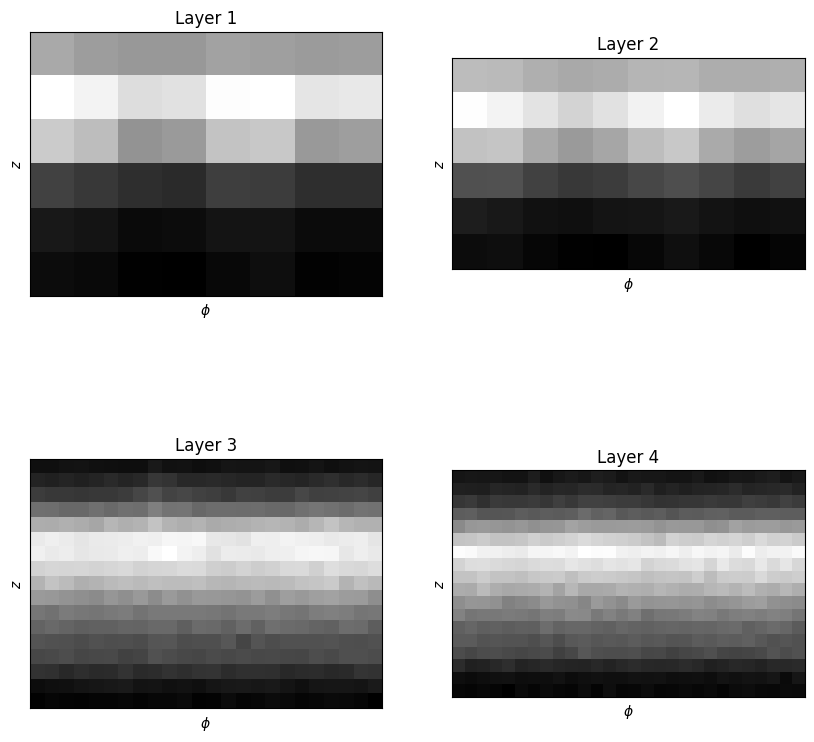

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
for iter, layer in enumerate(signal_images):
    ax[iter // 2, iter % 2].imshow(layer.sum(axis=0).squeeze().T, cmap="gray")
    ax[iter // 2, iter % 2].set_title(f"Layer {iter+1}")
    ax[iter // 2, iter % 2].set_xticks([])
    ax[iter // 2, iter % 2].set_xlabel(r"$\phi$")
    ax[iter // 2, iter % 2].set_yticks([])
    ax[iter // 2, iter % 2].set_ylabel(r"$z$")

In [7]:
from keras import layers


class CircularPadLayer(layers.Layer):
    """
    Circular padding along a chosen spatial axis for N-D tensors.

    Args:
        pad (int): Number of values to wrap on each side.
        axis (int): Axis along which to pad (positive or negative indexing).
    """

    def __init__(self, pad=1, axis=1, **kwargs):
        super().__init__(**kwargs)
        self.pad = pad
        self.axis = axis

    def call(self, inputs):
        # Ensure axis is positive
        axis = self.axis if self.axis >= 0 else len(inputs.shape) + self.axis

        # Slice from end and start to wrap
        pre_pad = tf.gather(
            inputs, indices=tf.range(-self.pad, 0) % tf.shape(inputs)[axis], axis=axis
        )
        post_pad = tf.gather(inputs, indices=tf.range(0, self.pad), axis=axis)
        return tf.concat([pre_pad, inputs, post_pad], axis=axis)

    def get_config(self):
        config = super().get_config()
        config.update({"pad": self.pad, "axis": self.axis})
        return config

In [8]:
layer_shapes = [layer.shape[1:] for layer in signal_images]

In [9]:
layer_inputs = [keras.Input(shape=shape) for shape in layer_shapes]

In [10]:
def create_conv_model(inputs):
    x = CircularPadLayer(pad=2, axis=PHI_AXIS)(inputs)
    x = layers.Conv2D(8, (5, 3), padding="valid", activation="relu")(x)
    x = CircularPadLayer(pad=2, axis=PHI_AXIS)(x)
    x = layers.Conv2D(16, (5, 3), padding="valid", activation="relu")(x)
    x = layers.GlobalMaxPooling2D()(x)
    return x

In [11]:
conv_outputs = [create_conv_model(layer_input) for layer_input in layer_inputs]

In [12]:
latent_space = layers.Concatenate()(conv_outputs)

In [13]:
from src.model.components import MLP

output = MLP(1, num_layers=5, activation="sigmoid")(latent_space)

In [14]:
model = keras.Model(inputs=layer_inputs, outputs=output)

In [15]:
from sklearn.model_selection import train_test_split

layer_data = [
    np.concatenate([signal_images[i], background_images[i]], axis=0)
    for i in range(len(signal_images))
]
labels = [
    np.concatenate(
        [np.ones(signal_images[i].shape[0]), np.zeros(background_images[i].shape[0])],
        axis=0,
    )
    for i in range(len(signal_images))
]

train_data = []
train_labels = None
test_data = []
test_labels = None
for i in range(len(layer_data)):
    X_train, X_test, y_train, y_test = train_test_split(
        layer_data[i], labels[i], test_size=0.2, random_state=42
    )
    train_data.append(X_train)
    test_data.append(X_test)
    if train_labels is None:
        train_labels = y_train
    if test_labels is None:
        test_labels = y_test

In [16]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [17]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8, 6, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 10, 6, 1)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 24, 17, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 28, 18, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ circular_pad_layer  │ (None, 12, 6, 1)  │          0 │ input_layer[0][0] │
│ (CircularPadLayer)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ circular_pad_layer… │ (None, 14, 6, 1)  │          0 │ input_layer_1[0]… │
│ (CircularPadLayer)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ circular_pad_layer… │ (None, 28, 17, 1) │          0 │ input_layer_2[0]… │
│ (CircularPadLayer)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ circular_pad_layer… │ (None, 32, 18, 1) │          0 │ input_layer_3[0]… │
│ (CircularPadLayer)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 8, 4, 8)   │        128 │ circular_pad_lay… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 10, 4, 8)  │        128 │ circular_pad_lay… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 24, 15, 8) │        128 │ circular_pad_lay… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 28, 16, 8) │        128 │ circular_pad_lay… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ circular_pad_layer… │ (None, 12, 4, 8)  │          0 │ conv2d[0][0]      │
│ (CircularPadLayer)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ circular_pad_layer… │ (None, 14, 4, 8)  │          0 │ conv2d_2[0][0]    │
│ (CircularPadLayer)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ circular_pad_layer… │ (None, 28, 15, 8) │          0 │ conv2d_4[0][0]    │
│ (CircularPadLayer)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ circular_pad_layer… │ (None, 32, 16, 8) │          0 │ conv2d_6[0][0]    │
│ (CircularPadLayer)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 8, 2, 16)  │      1,936 │ circular_pad_lay… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 10, 2, 16) │      1,936 │ circular_pad_lay… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 24, 13,    │      1,936 │ circular_pad_lay

 Total params: 10,427 (40.73 KB)

 Trainable params: 10,427 (40.73 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.fit(train_data, train_labels, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
3655/3655 ━━━━━━━━━━━━━━━━━━━━ 70s 18ms/step - accuracy: 0.6192 - loss: 0.6485 - val_accuracy: 0.6289 - val_loss: 0.6415
Epoch 2/10
3655/3655 ━━━━━━━━━━━━━━━━━━━━ 63s 17ms/step - accuracy: 0.6336 - loss: 0.6375 - val_accuracy: 0.6263 - val_loss: 0.6391
Epoch 3/10
3655/3655 ━━━━━━━━━━━━━━━━━━━━ 64s 17ms/step - accuracy: 0.6378 - loss: 0.6337 - val_accuracy: 0.6339 - val_loss: 0.6367
Epoch 4/10
3655/3655 ━━━━━━━━━━━━━━━━━━━━ 66s 18ms/step - accuracy: 0.6401 - loss: 0.6317 - val_accuracy: 0.6341 - val_loss: 0.6366
Epoch 5/10
3655/3655 ━━━━━━━━━━━━━━━━━━━━ 66s 18ms/step - accuracy: 0.6435 - loss: 0.6304 - val_accuracy: 0.6357 - val_loss: 0.6355
Epoch 6/10
3655/3655 ━━━━━━━━━━━━━━━━━━━━ 66s 18ms/step - accuracy: 0.6445 - loss: 0.6289 - val_accuracy: 0.6378 - val_loss: 0.6346
Epoch 7/10
3655/3655 ━━━━━━━━━━━━━━━━━━━━ 62s 17ms/step - accuracy: 0.6448 - loss: 0.6274 - val_accuracy: 0.6388 - val_loss: 0.6354
Epoch 8/10
3655/3655 ━━━━━━━━━━━━━━━━━━━━ 61s 17ms/step - accuracy: 0.6481 -

1143/1143 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


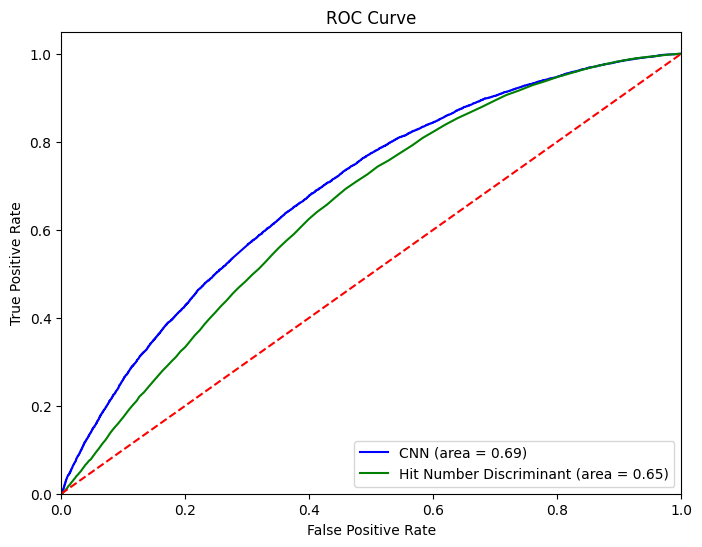

In [27]:
from sklearn.metrics import roc_curve, auc

y_pred_test = model.predict(test_data)
test_num_hits = compute_hit_number(test_data)
fpr, tpr, thresholds = roc_curve(test_labels, y_pred_test)
fpr_num_hit, tpr_num_hit, thresholds_num_hit = roc_curve(
    test_labels,
    test_num_hits,
)
roc_auc = auc(fpr, tpr)
roc_auc_num_hit = auc(fpr_num_hit, tpr_num_hit)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", label="CNN (area = {:.2f})".format(roc_auc))
plt.plot(
    fpr_num_hit,
    tpr_num_hit,
    color="green",
    label="Hit Number Discriminant (area = {:.2f})".format(roc_auc_num_hit),
)
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.savefig(PLOTS_DIR + "/cnn_roc_curve.png")

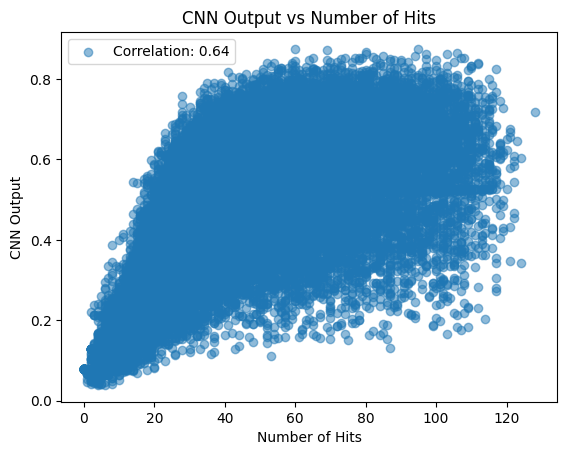

In [28]:
plt.scatter(
    test_num_hits,
    y_pred_test,
    label=f"Correlation: {np.corrcoef(test_num_hits, y_pred_test.flatten())[0, 1]:.2f}",
    alpha=0.5,
)
plt.xlabel("Number of Hits")
plt.ylabel("CNN Output")
plt.title("CNN Output vs Number of Hits")
plt.legend()
plt.savefig(PLOTS_DIR + "/cnn_output_vs_num_hits.png")

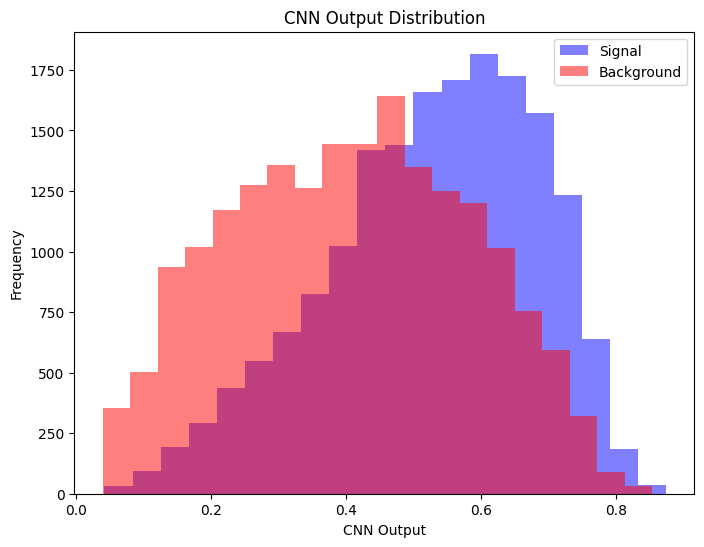

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.hist(
    y_pred_test[test_labels == 1],
    bins=20,
    alpha=0.5,
    label="Signal",
    color="blue",
)
ax.hist(
    y_pred_test[test_labels == 0],
    bins=20,
    alpha=0.5,
    label="Background",
    color="red",
)
ax.set_xlabel("CNN Output")
ax.set_ylabel("Frequency")
ax.set_title("CNN Output Distribution")
ax.legend()
plt.savefig(PLOTS_DIR + "/cnn_output_distribution.png")

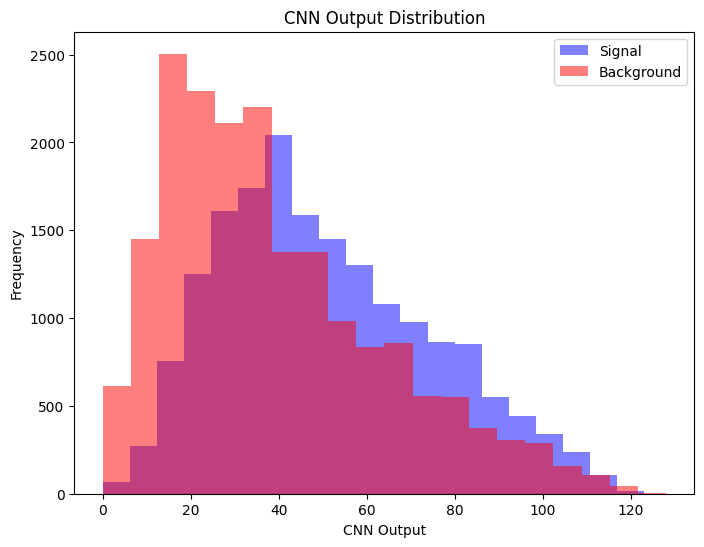

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.hist(
    test_num_hits[test_labels == 1],
    bins=20,
    alpha=0.5,
    label="Signal",
    color="blue",
)
ax.hist(
    test_num_hits[test_labels == 0],
    bins=20,
    alpha=0.5,
    label="Background",
    color="red",
)
ax.set_xlabel("CNN Output")
ax.set_ylabel("Frequency")
ax.set_title("CNN Output Distribution")
ax.legend()
plt.savefig(PLOTS_DIR + "/cnn_output_distribution.png")